PPM图像1尺寸：(512, 765)，图像2尺寸：(512, 765)
PPM图像1检测到特征点数量：4780
PPM图像2检测到特征点数量：4442
筛选后有效匹配对数量：2198


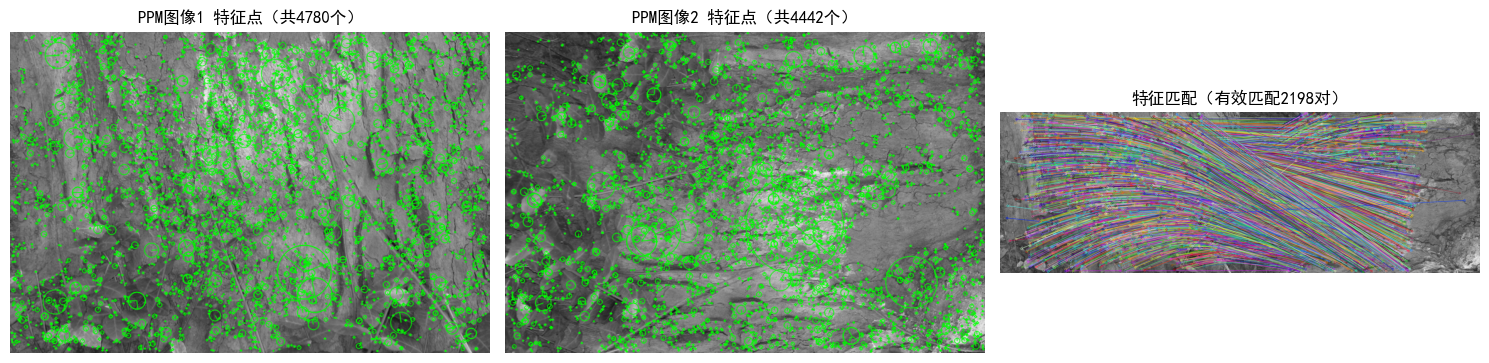

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 解决matplotlib中文显示问题（可选）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def surf_sift_feature_matching(img1_path, img2_path):
    """
    用SIFT替代SURF实现特征检测匹配（兼容PPM格式，无专利限制）
    :param img1_path: 第一张PPM图像路径
    :param img2_path: 第二张PPM图像路径
    """
    # -------------------------- 1. 读取PPM图像 --------------------------
    img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None:
        print("错误：PPM图像读取失败！")
        print(f"检查路径：\n  img1: {img1_path}\n  img2: {img2_path}")
        return

    print(f"PPM图像1尺寸：{img1.shape}，图像2尺寸：{img2.shape}")

    # -------------------------- 2. 初始化SIFT检测器（替代SURF） --------------------------
    # SIFT无专利限制，接口与SURF完全兼容
    sift = cv2.SIFT_create(
        nfeatures=0,          # 检测的最大特征点数（0=无限制）
        nOctaveLayers=3,      # 每个八度的尺度层数（与SURF一致）
        contrastThreshold=0.04,# 对比度阈值（替代SURF的Hessian阈值，值越小特征点越多）
        edgeThreshold=10,     # 边缘阈值（过滤边缘特征点）
        sigma=1.6             # 初始高斯核sigma（与SURF的1.2接近）
    )

    # -------------------------- 3. 检测特征点+计算描述子 --------------------------
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    print(f"PPM图像1检测到特征点数量：{len(kp1)}")
    print(f"PPM图像2检测到特征点数量：{len(kp2)}")

    # 绘制特征点
    img1_kp = cv2.drawKeypoints(img1, kp1, None, (0, 255, 0),
                                cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    img2_kp = cv2.drawKeypoints(img2, kp2, None, (0, 255, 0),
                                cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    # -------------------------- 4. 特征匹配 --------------------------
    # FLANN匹配器（适配大量特征点）
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    matches = flann.knnMatch(des1, des2, k=2)

    # 筛选正确匹配（NNDR<0.8）
    good_matches = []
    for m, n in matches:
        if m.distance < 0.8 * n.distance:
            good_matches.append(m)

    print(f"筛选后有效匹配对数量：{len(good_matches)}")

    # 绘制匹配结果
    img_matches = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None,
                                  flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # -------------------------- 5. 可视化 --------------------------
    plt.figure(figsize=(15, 8))
    plt.subplot(1, 3, 1)
    plt.imshow(img1_kp, cmap='gray')
    plt.title(f'PPM图像1 特征点（共{len(kp1)}个）')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(img2_kp, cmap='gray')
    plt.title(f'PPM图像2 特征点（共{len(kp2)}个）')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(img_matches)
    plt.title(f'特征匹配（有效匹配{len(good_matches)}对）')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# -------------------------- 运行代码 --------------------------
if __name__ == "__main__":
    # 替换为你的PPM图像路径
    img1_path = "bark/img4.ppm"
    img2_path = "bark/img5.ppm"
    surf_sift_feature_matching(img1_path, img2_path)

PPM图像1尺寸：(512, 765)，图像2尺寸：(512, 765)
PPM图像1检测到特征点数量：4780
PPM图像2检测到特征点数量：4442
筛选后有效匹配对数量：50


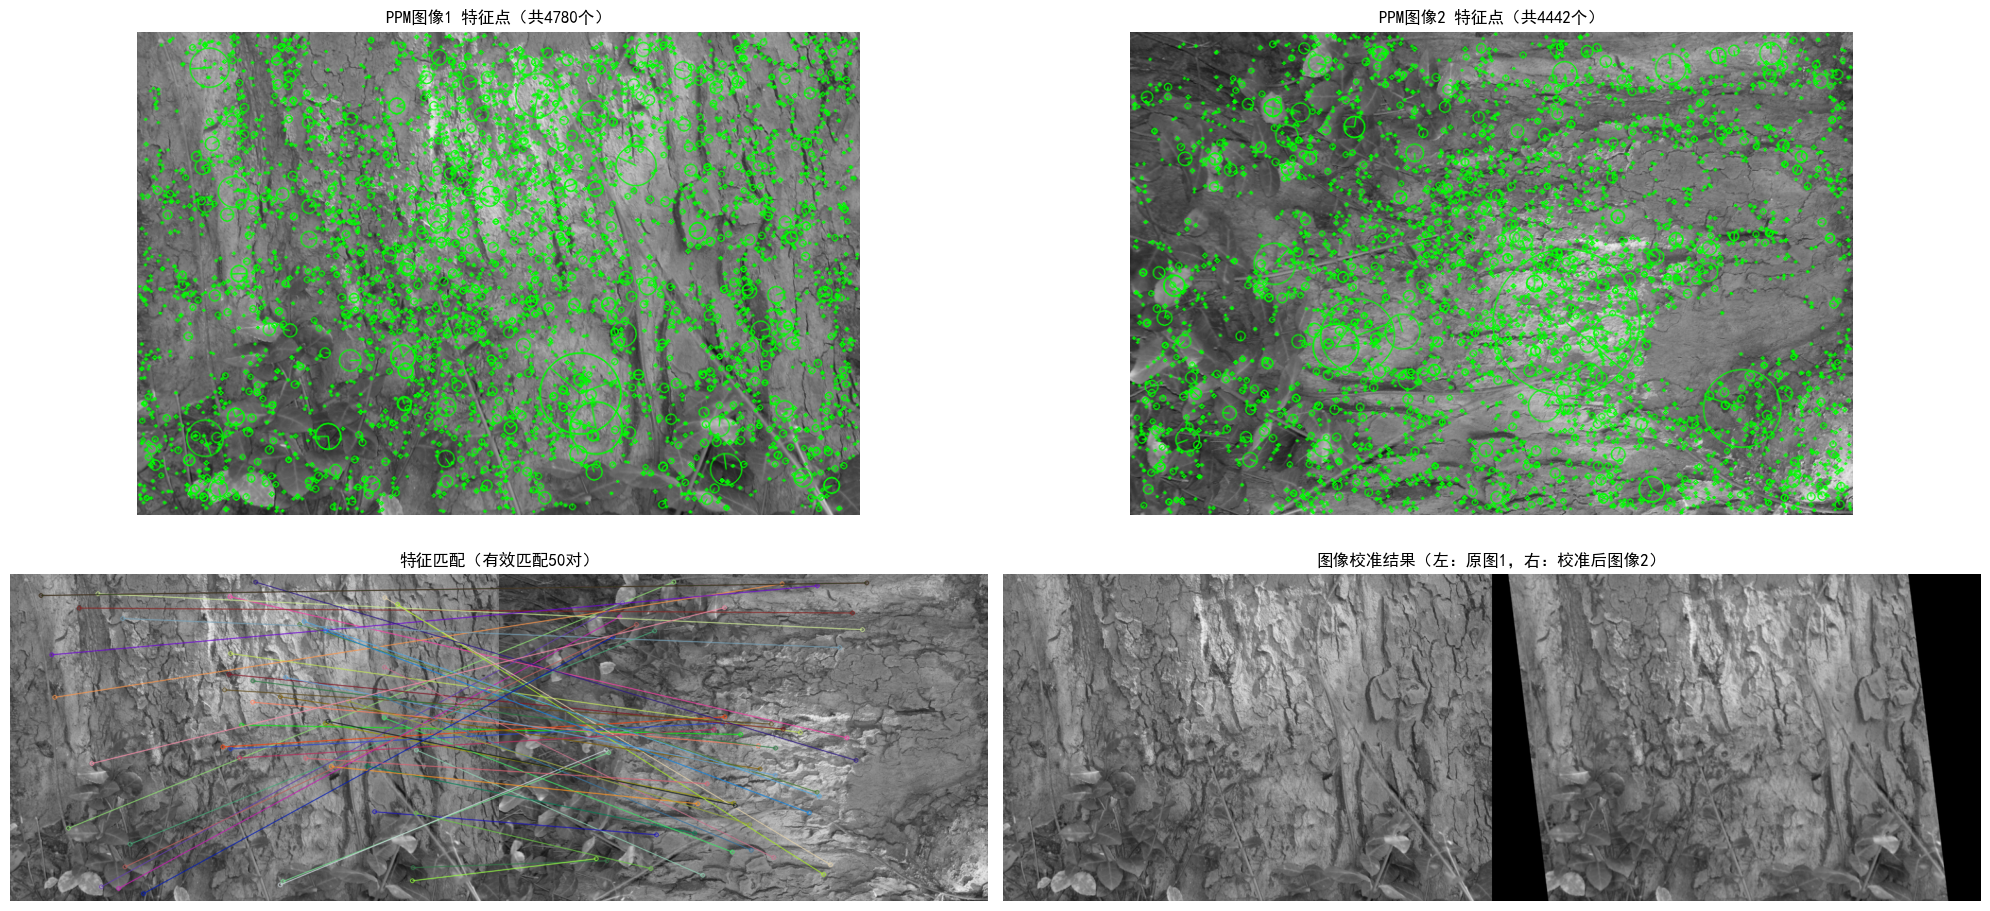

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 解决matplotlib中文显示问题（可选）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def surf_sift_feature_matching(img1_path, img2_path):
    """
    用SIFT替代SURF实现特征检测匹配+图像校准（兼容PPM格式，可控制匹配数量）
    :param img1_path: 第一张PPM图像路径（参考图像）
    :param img2_path: 第二张PPM图像路径（待校准图像）
    """
    # -------------------------- 1. 读取PPM图像 --------------------------
    img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None:
        print("错误：PPM图像读取失败！")
        print(f"检查路径：\n  img1: {img1_path}\n  img2: {img2_path}")
        return

    # 保存彩色版本用于校准后显示（灰度图用于特征检测，彩色图用于可视化）
    img1_color = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
    img2_color = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)
    print(f"PPM图像1尺寸：{img1.shape}，图像2尺寸：{img2.shape}")

    # -------------------------- 2. 初始化SIFT检测器（替代SURF） --------------------------
    sift = cv2.SIFT_create(
        nfeatures=0,          # 检测的最大特征点数（0=无限制）
        nOctaveLayers=3,      # 每个八度的尺度层数（与SURF一致）
        contrastThreshold=0.04,# 对比度阈值（值越小特征点越多）
        edgeThreshold=10,     # 边缘阈值（过滤边缘特征点）
        sigma=1.6             # 初始高斯核sigma
    )

    # -------------------------- 3. 检测特征点+计算描述子 --------------------------
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    print(f"PPM图像1检测到特征点数量：{len(kp1)}")
    print(f"PPM图像2检测到特征点数量：{len(kp2)}")

    # 绘制特征点
    img1_kp = cv2.drawKeypoints(img1, kp1, None, (0, 255, 0),
                                cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    img2_kp = cv2.drawKeypoints(img2, kp2, None, (0, 255, 0),
                                cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    # -------------------------- 4. 特征匹配（可控制匹配数量） --------------------------
    # FLANN匹配器
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    matches = flann.knnMatch(des1, des2, k=2)

    # 1. 筛选正确匹配（调小NNDR阈值，减少匹配对数量）
    # 原NNDR=0.8 → 改为0.7，匹配更严格，数量更少；值越小匹配越少、越精准
    good_matches = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:  # 核心修改：降低NNDR阈值减少匹配对
            good_matches.append(m)

    # 2. 可选：直接限制最大匹配数量（比如只保留前50个最优匹配）
    good_matches = sorted(good_matches, key=lambda x: x.distance)[:50]  # 新增：限制最多50个匹配对

    print(f"筛选后有效匹配对数量：{len(good_matches)}")

    # 绘制匹配结果
    img_matches = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None,
                                  flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # -------------------------- 5. 图像校准（配准） --------------------------
    if len(good_matches) >= 4:  # 单应性变换至少需要4个匹配对
        # 提取匹配点的坐标
        pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        # 计算单应性矩阵（RANSAC剔除异常值，提升校准精度）
        H, mask = cv2.findHomography(pts2, pts1, cv2.RANSAC, 5.0)
        matches_mask = mask.ravel().tolist()

        # 对图像2进行校准（变换到图像1的坐标系）
        h, w = img1.shape
        img2_aligned = cv2.warpPerspective(img2_color, H, (w, h))

        # 绘制校准后的对比图
        img_align_compare = np.hstack((img1_color, img2_aligned))  # 横向拼接原图和校准图
    else:
        print("警告：匹配对数量不足（<4），无法完成图像校准！")
        img_align_compare = np.hstack((img1_color, img2_color))
        matches_mask = None

    # -------------------------- 6. 结果可视化 --------------------------
    plt.figure(figsize=(20, 10))

    # 子图1：图像1特征点
    plt.subplot(2, 2, 1)
    plt.imshow(img1_kp, cmap='gray')
    plt.title(f'PPM图像1 特征点（共{len(kp1)}个）')
    plt.axis('off')

    # 子图2：图像2特征点
    plt.subplot(2, 2, 2)
    plt.imshow(img2_kp, cmap='gray')
    plt.title(f'PPM图像2 特征点（共{len(kp2)}个）')
    plt.axis('off')

    # 子图3：特征匹配结果
    plt.subplot(2, 2, 3)
    plt.imshow(img_matches)
    plt.title(f'特征匹配（有效匹配{len(good_matches)}对）')
    plt.axis('off')

    # 子图4：图像校准结果
    plt.subplot(2, 2, 4)
    plt.imshow(cv2.cvtColor(img_align_compare, cv2.COLOR_BGR2RGB))
    plt.title('图像校准结果（左：原图1，右：校准后图像2）')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# -------------------------- 运行代码 --------------------------
if __name__ == "__main__":
    # 替换为你的PPM图像路径
    img1_path = "bark/img4.ppm"
    img2_path = "bark/img5.ppm"
    surf_sift_feature_matching(img1_path, img2_path)

成功加载6张PPM图像：['bark/img1.ppm', 'bark/img2.ppm', 'bark/img3.ppm', 'bark/img4.ppm', 'bark/img5.ppm', 'bark/img6.ppm']


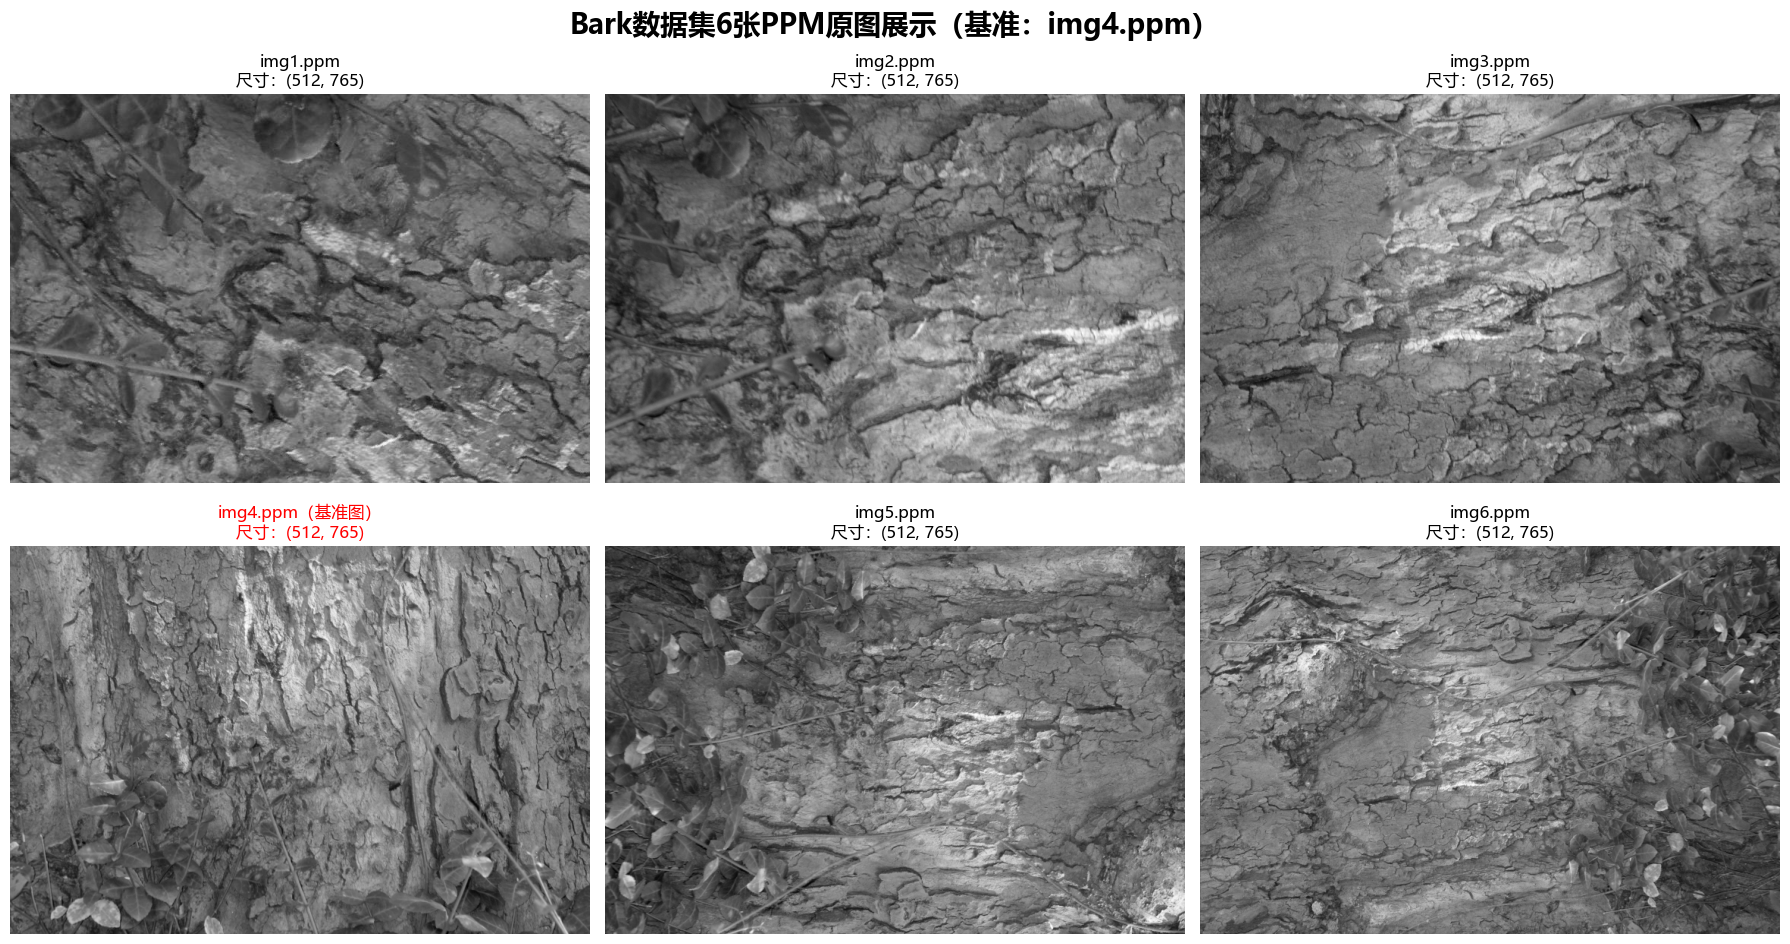

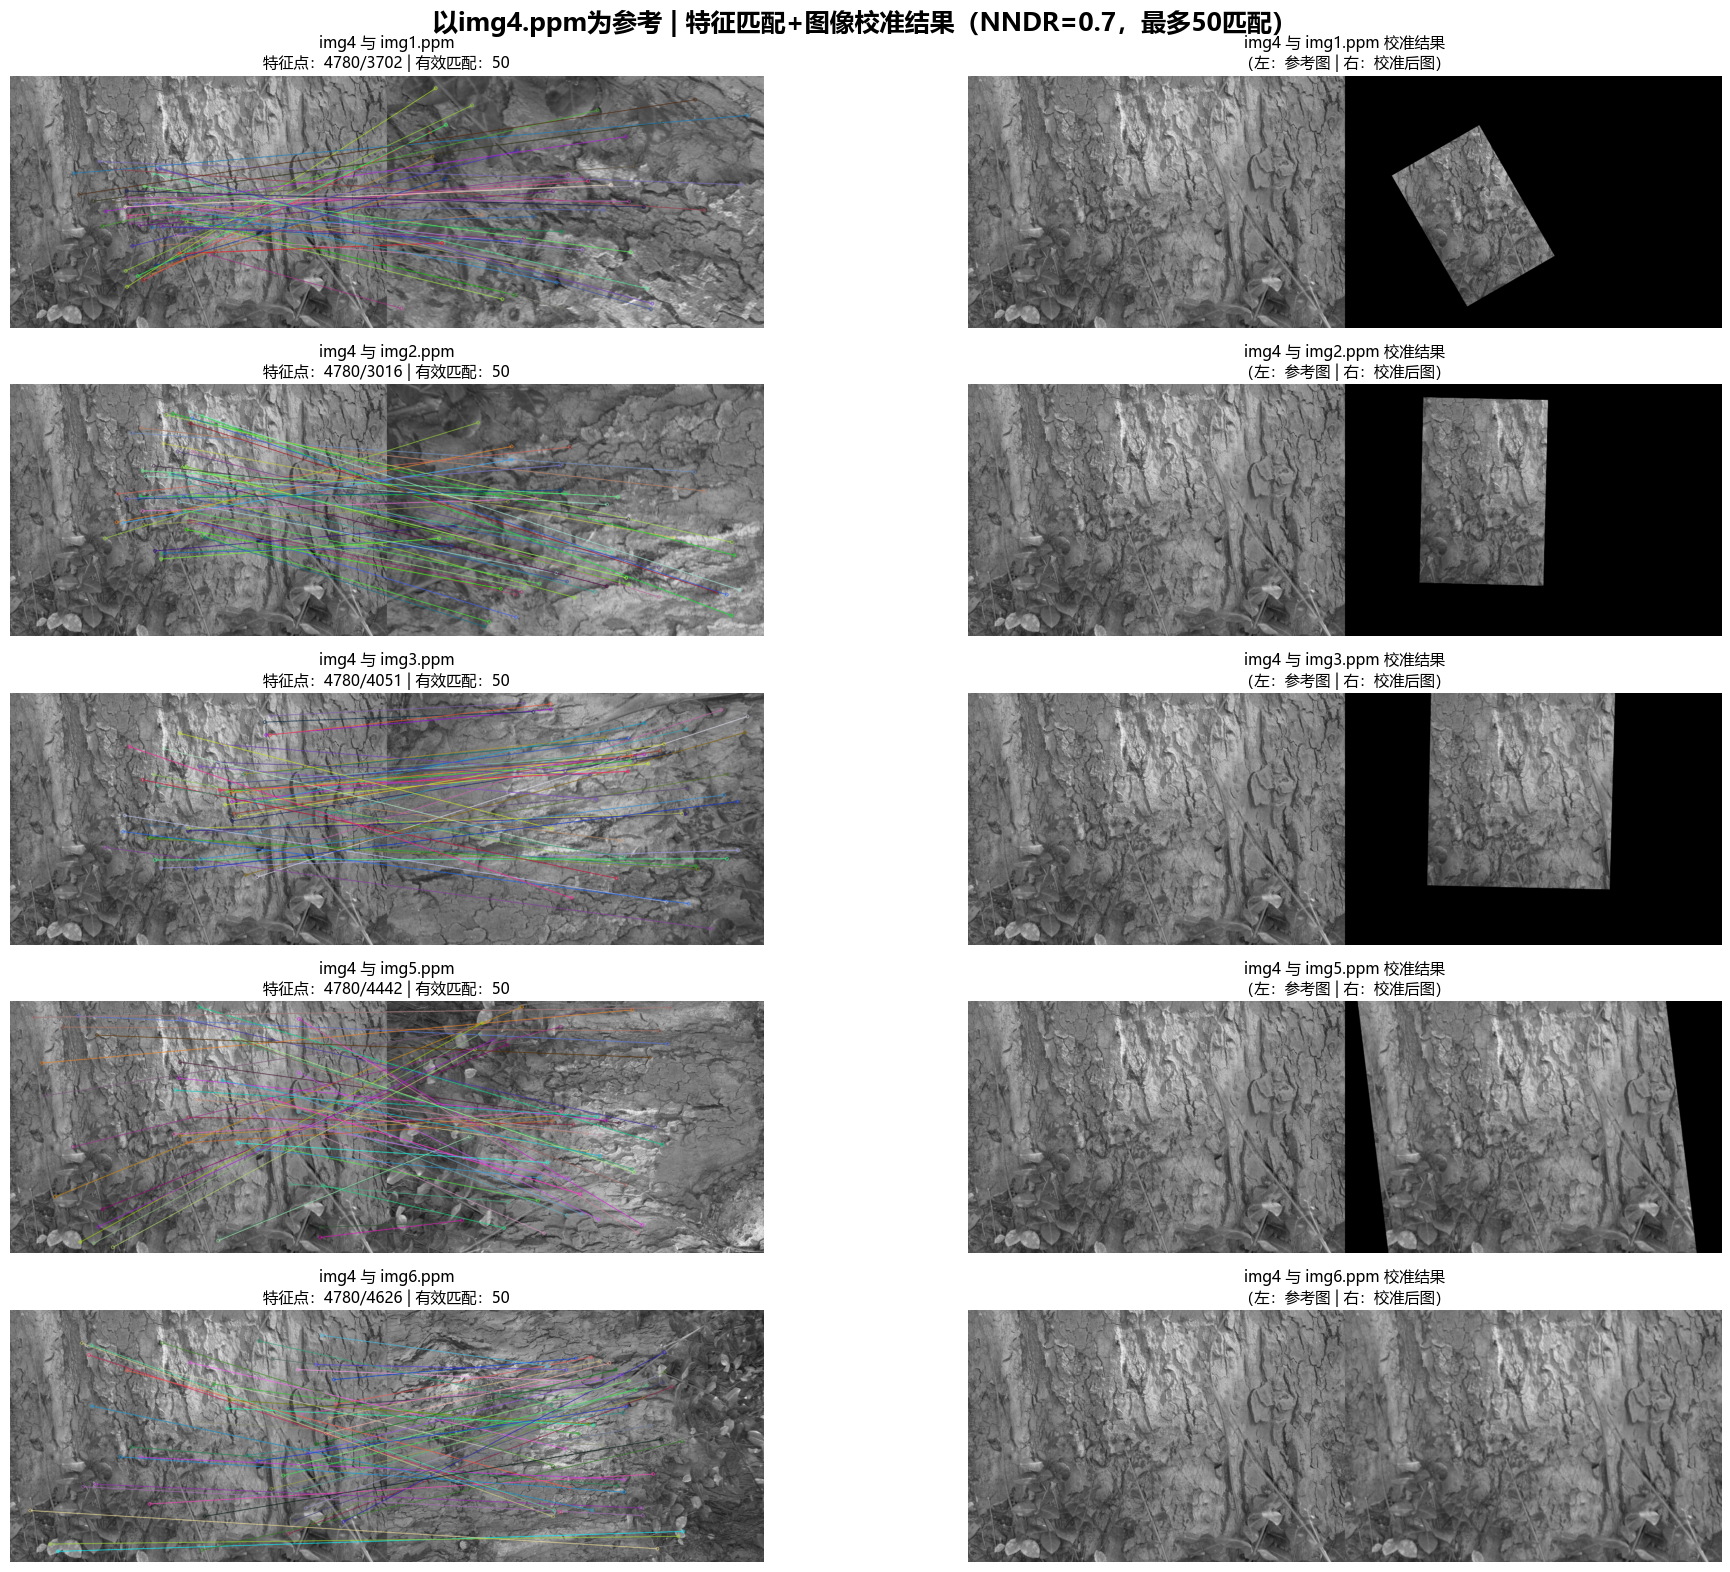

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# 解决matplotlib中文+特殊符号显示问题（核心修复）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']  # 增加备用字体
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'sans-serif'  # 指定字体族
# 设置matplotlib显示风格
plt.rcParams['figure.facecolor'] = 'white'

def load_ppm_images(base_path, img_nums):
    """批量加载PPM灰度图像和彩色图像"""
    imgs_gray = []  # 灰度图（用于特征检测）
    imgs_color = [] # 彩色图（用于可视化和校准）
    img_paths = []  # 图像路径
    for num in img_nums:
        path = f"{base_path}/img{num}.ppm"
        if not os.path.exists(path):
            print(f"警告：文件不存在 → {path}")
            continue
        img_gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img_color = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
        imgs_gray.append(img_gray)
        imgs_color.append(img_color)
        img_paths.append(path)
    return imgs_gray, imgs_color, img_paths

def sift_feature_match_align(img1_gray, img2_gray, img1_color, img2_color):
    """单组SIFT特征匹配+图像校准（返回匹配图、校准对比图、匹配数）"""
    # 初始化SIFT检测器
    sift = cv2.SIFT_create(
        nfeatures=0,
        nOctaveLayers=3,
        contrastThreshold=0.04,
        edgeThreshold=10,
        sigma=1.6
    )
    # 检测特征点+计算描述子
    kp1, des1 = sift.detectAndCompute(img1_gray, None)
    kp2, des2 = sift.detectAndCompute(img2_gray, None)
    # FLANN匹配器
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des1, des2, k=2)
    # 严格筛选匹配对（减少数量，NNDR=0.7+限制前50）
    good_matches = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)
    # 按相似度排序，保留前50个最优匹配
    good_matches = sorted(good_matches, key=lambda x: x.distance)[:50]
    match_num = len(good_matches)
    # 绘制匹配图
    img_matches = cv2.drawMatches(
        img1_gray, kp1, img2_gray, kp2, good_matches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    # 图像校准（单应性变换）
    if match_num >= 4:
        pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        H, _ = cv2.findHomography(pts2, pts1, cv2.RANSAC, 5.0)
        h, w = img1_gray.shape
        img2_aligned = cv2.warpPerspective(img2_color, H, (w, h))
    else:
        img2_aligned = img2_color
    # 拼接校准对比图（左：参考图，右：校准后图）
    img_align = np.hstack((img1_color, img2_aligned))
    return img_matches, img_align, match_num, kp1, kp2

def show_6_origin_imgs(imgs_gray, img_paths):
    """展示6张PPM原图（灰度）"""
    plt.figure(figsize=(18, 10))
    plt.suptitle('Bark数据集6张PPM原图展示（基准：img4.ppm）', fontsize=20, fontweight='bold')
    for i in range(6):
        plt.subplot(2, 3, i+1)
        plt.imshow(imgs_gray[i], cmap='gray')
        # 标注基准图（img4），去掉特殊符号，用文字替代
        if i == 3:  # 索引3对应img4
            plt.title(f'img{i+1}.ppm（基准图）\n尺寸：{imgs_gray[i].shape}', fontsize=12, color='red')
        else:
            plt.title(f'img{i+1}.ppm\n尺寸：{imgs_gray[i].shape}', fontsize=12)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def batch_match_align(imgs_gray, imgs_color, ref_idx=3):
    """批量匹配：以第4张（img4，索引3）为参考，匹配其余5张并校准"""
    ref_gray = imgs_gray[ref_idx]
    ref_color = imgs_color[ref_idx]
    match_align_imgs = []  # 存储每组的[匹配图, 校准图]
    match_nums = []        # 存储每组匹配数
    kp_nums = []           # 存储每组特征点数
    match_img_nums = []    # 存储匹配的图像编号（用于标题）

    # 定义匹配顺序：img1、img2、img3、img5、img6（排除img4自身）
    match_indices = [0,1,2,4,5]  # 对应img1、img2、img3、img5、img6的索引
    match_img_num_list = [1,2,3,5,6]  # 对应图像编号

    # 逐张匹配其余5张图
    for idx, img_num in zip(match_indices, match_img_num_list):
        img_matches, img_align, match_num, kp1, kp2 = sift_feature_match_align(
            ref_gray, imgs_gray[idx], ref_color, imgs_color[idx]
        )
        match_align_imgs.append([img_matches, img_align])
        match_nums.append(match_num)
        kp_nums.append([len(kp1), len(kp2)])
        match_img_nums.append(img_num)

    # 可视化所有匹配+校准结果
    plt.figure(figsize=(20, 16))
    # 标题去掉特殊符号，用文字描述替代
    plt.suptitle(f'以img4.ppm为参考 | 特征匹配+图像校准结果（NNDR=0.7，最多50匹配）',
                 fontsize=18, fontweight='bold')
    for i in range(5):
        # 子图1：特征匹配图（第i+1行第1列）
        plt.subplot(5, 2, 2*i+1)
        plt.imshow(match_align_imgs[i][0], cmap='gray')
        # 核心修复：去掉↔符号，用"与"替代，避免字体缺失警告
        plt.title(f'img4 与 img{match_img_nums[i]}.ppm\n特征点：{kp_nums[i][0]}/{kp_nums[i][1]} | 有效匹配：{match_nums[i]}',
                  fontsize=11)
        plt.axis('off')
        # 子图2：校准对比图（第i+1行第2列）
        plt.subplot(5, 2, 2*i+2)
        plt.imshow(cv2.cvtColor(match_align_imgs[i][1], cv2.COLOR_BGR2RGB))
        # 核心修复：去掉↔符号，用"与"替代
        plt.title(f'img4 与 img{match_img_nums[i]}.ppm 校准结果\n（左：参考图 | 右：校准后图）',
                  fontsize=11)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# -------------------------- 主函数：一键运行 --------------------------
if __name__ == "__main__":
    # 配置路径和图像编号（img1~img6）
    BASE_PATH = "bark"  # 图像根目录
    IMG_NUMS = [1,2,3,4,5,6]  # 图像编号
    # 批量加载图像
    imgs_gray, imgs_color, img_paths = load_ppm_images(BASE_PATH, IMG_NUMS)
    if len(imgs_gray) != 6:
        print(f"错误：未加载到6张图像，实际加载{len(imgs_gray)}张！")
    else:
        print(f"成功加载6张PPM图像：{img_paths}")
        # 第一步：展示6张原图（标注img4为基准）
        show_6_origin_imgs(imgs_gray, img_paths)
        # 第二步：以img4为参考（索引3），批量匹配其余5张 + 图像校准
        batch_match_align(imgs_gray, imgs_color, ref_idx=3)